In [11]:
#install if needed

#%pip install rasterio

In [24]:
# This can either be:
# 1) a single dataset folder containing images/ and labels/ such as the Thomas dataset
# OR
# 2) a parent folder containing multiple dataset folders such as the ThosandOaks dataset
#
# BASE_DIR = "/home/pid/Z1_Roads_Thomas" if 
# BASE_DIR = "/home/pid/Corona/Z6_CalFire_BlueRidge"

BASE_DIR = "C:\\Users\\dylan\\Downloads\\capstoneData\\San Fernando\\San Fernando"

In [25]:
import os
from collections import Counter
import numpy as np
import rasterio

#reads a label file (mask) and will return the 2d numpy array
def read_mask(path):
    with rasterio.open(path) as src:
        return src.read(1)
#checks if a folder is a dataset (contains images and labels folders)
def is_dataset_folder(path):
    if not os.path.isdir(path):
        return False
    contents = os.listdir(path)
    return "images" in contents and "labels" in contents

    
# Determines if BASE_DIR is a single dataset like Thomas or
# a folder with many datasets like Corona
def get_dataset_folders(base_dir):
    # Case 1: base_dir itself is a dataset folder
    if is_dataset_folder(base_dir):
        return [base_dir]

    # Case 2: base_dir contains multiple dataset folders
    dataset_paths = []
    for name in sorted(os.listdir(base_dir)):
        full_path = os.path.join(base_dir, name)
        if is_dataset_folder(full_path):
            dataset_paths.append(full_path)

    return dataset_paths
#gets all dataset paths for inpection
dataset_paths = get_dataset_folders(BASE_DIR)

# error if no dataset is found
if not dataset_paths:
    raise ValueError(
        "No dataset folders found. Make sure BASE_DIR points either to "
        "a dataset folder with images/ and labels/, or to a parent folder "
        "containing dataset folders."
    )

print("\n===== DATA INSPECTION SUMMARY =====\n")

# loops through each dataset
for dataset_path in dataset_paths:
    dataset_name = os.path.basename(dataset_path)
    # sets images_dir and labels_dir
    images_dir = os.path.join(dataset_path, "images")
    labels_dir = os.path.join(dataset_path, "labels")

    print(f"--- {dataset_name} ---")

    # Gets all image and label filenames
    image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(".tif")])
    label_files = sorted([f for f in os.listdir(labels_dir) if f.lower().endswith(".tif")])

    # Matches images to masks by filename
    image_bases = {os.path.splitext(f)[0] for f in image_files}
    label_bases = {os.path.splitext(f)[0] for f in label_files}

    missing_labels = sorted(image_bases - label_bases)
    missing_images = sorted(label_bases - image_bases)
    matched_bases = sorted(image_bases & label_bases)

    # dataset info
    print("Image files:", len(image_files))
    print("Label files:", len(label_files))
    print("Matched pairs:", len(matched_bases))
    print("Images with no label:", len(missing_labels))
    print("Labels with no image:", len(missing_images))

    #will skip the dataset if no valid image/mask pairs
    if len(matched_bases) == 0:
        print("No matched pairs found.\n")
        continue
    
    # Statistic counters
    pixel_counter = Counter() #pixel per class
    classes_present = set() # unique classes
    shape_mismatches = 0 # image/mask size mismatches

    # Loops through all image/label pairs
    for i, base in enumerate(matched_bases):
        img_path = os.path.join(images_dir, base + ".tif")
        lbl_path = os.path.join(labels_dir, base + ".tif")

        # gets image shape
        with rasterio.open(img_path) as src:
            img_shape = (src.height, src.width)
        # label shape
        lbl = read_mask(lbl_path)
        lbl_shape = lbl.shape

        # checking image shape = label shape
        if img_shape != lbl_shape:
            shape_mismatches += 1

        # counts number of classes in label and how many pixels in each
        vals, counts = np.unique(lbl, return_counts=True)
        classes_present.update(vals.tolist())

        for v, c in zip(vals, counts):
            pixel_counter[int(v)] += int(c)

    total_pixels = sum(pixel_counter.values())

    # prints the stats
    print("Classes present:", sorted(int(v) for v in classes_present))
    print("Number of classes present:", len(classes_present))
    print("Shape mismatches:", shape_mismatches)
    print("Label distribution:")

    # print percentage of each class
    for val in sorted(pixel_counter):
        pct = 100 * pixel_counter[val] / total_pixels
        print(f"  Label {val}: {pct:.2f}%")

    print()

print("===== DONE =====")


===== DATA INSPECTION SUMMARY =====

--- Z3_CalFire_Creek ---
Image files: 2377
Label files: 2377
Matched pairs: 2377
Images with no label: 0
Labels with no image: 0
Classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Number of classes present: 13
Shape mismatches: 0
Label distribution:
  Label 0: 44.33%
  Label 1: 0.01%
  Label 2: 8.18%
  Label 3: 0.00%
  Label 4: 2.56%
  Label 5: 0.01%
  Label 6: 0.12%
  Label 7: 0.08%
  Label 8: 5.37%
  Label 9: 0.04%
  Label 10: 1.91%
  Label 11: 11.18%
  Label 12: 26.22%

--- Z3_CalFire_LaTuna ---
Image files: 2377
Label files: 2377
Matched pairs: 2377
Images with no label: 0
Labels with no image: 0
Classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Number of classes present: 13
Shape mismatches: 0
Label distribution:
  Label 0: 44.33%
  Label 1: 0.01%
  Label 2: 8.18%
  Label 3: 0.00%
  Label 4: 2.56%
  Label 5: 0.01%
  Label 6: 0.12%
  Label 7: 0.08%
  Label 8: 5.37%
  Label 9: 0.04%
  Label 10: 1.91%
  Label 11: 11.18%
  Label

Using dataset: Z3_CalFire_SaddleRidge2
Matched image-label pairs: 2377


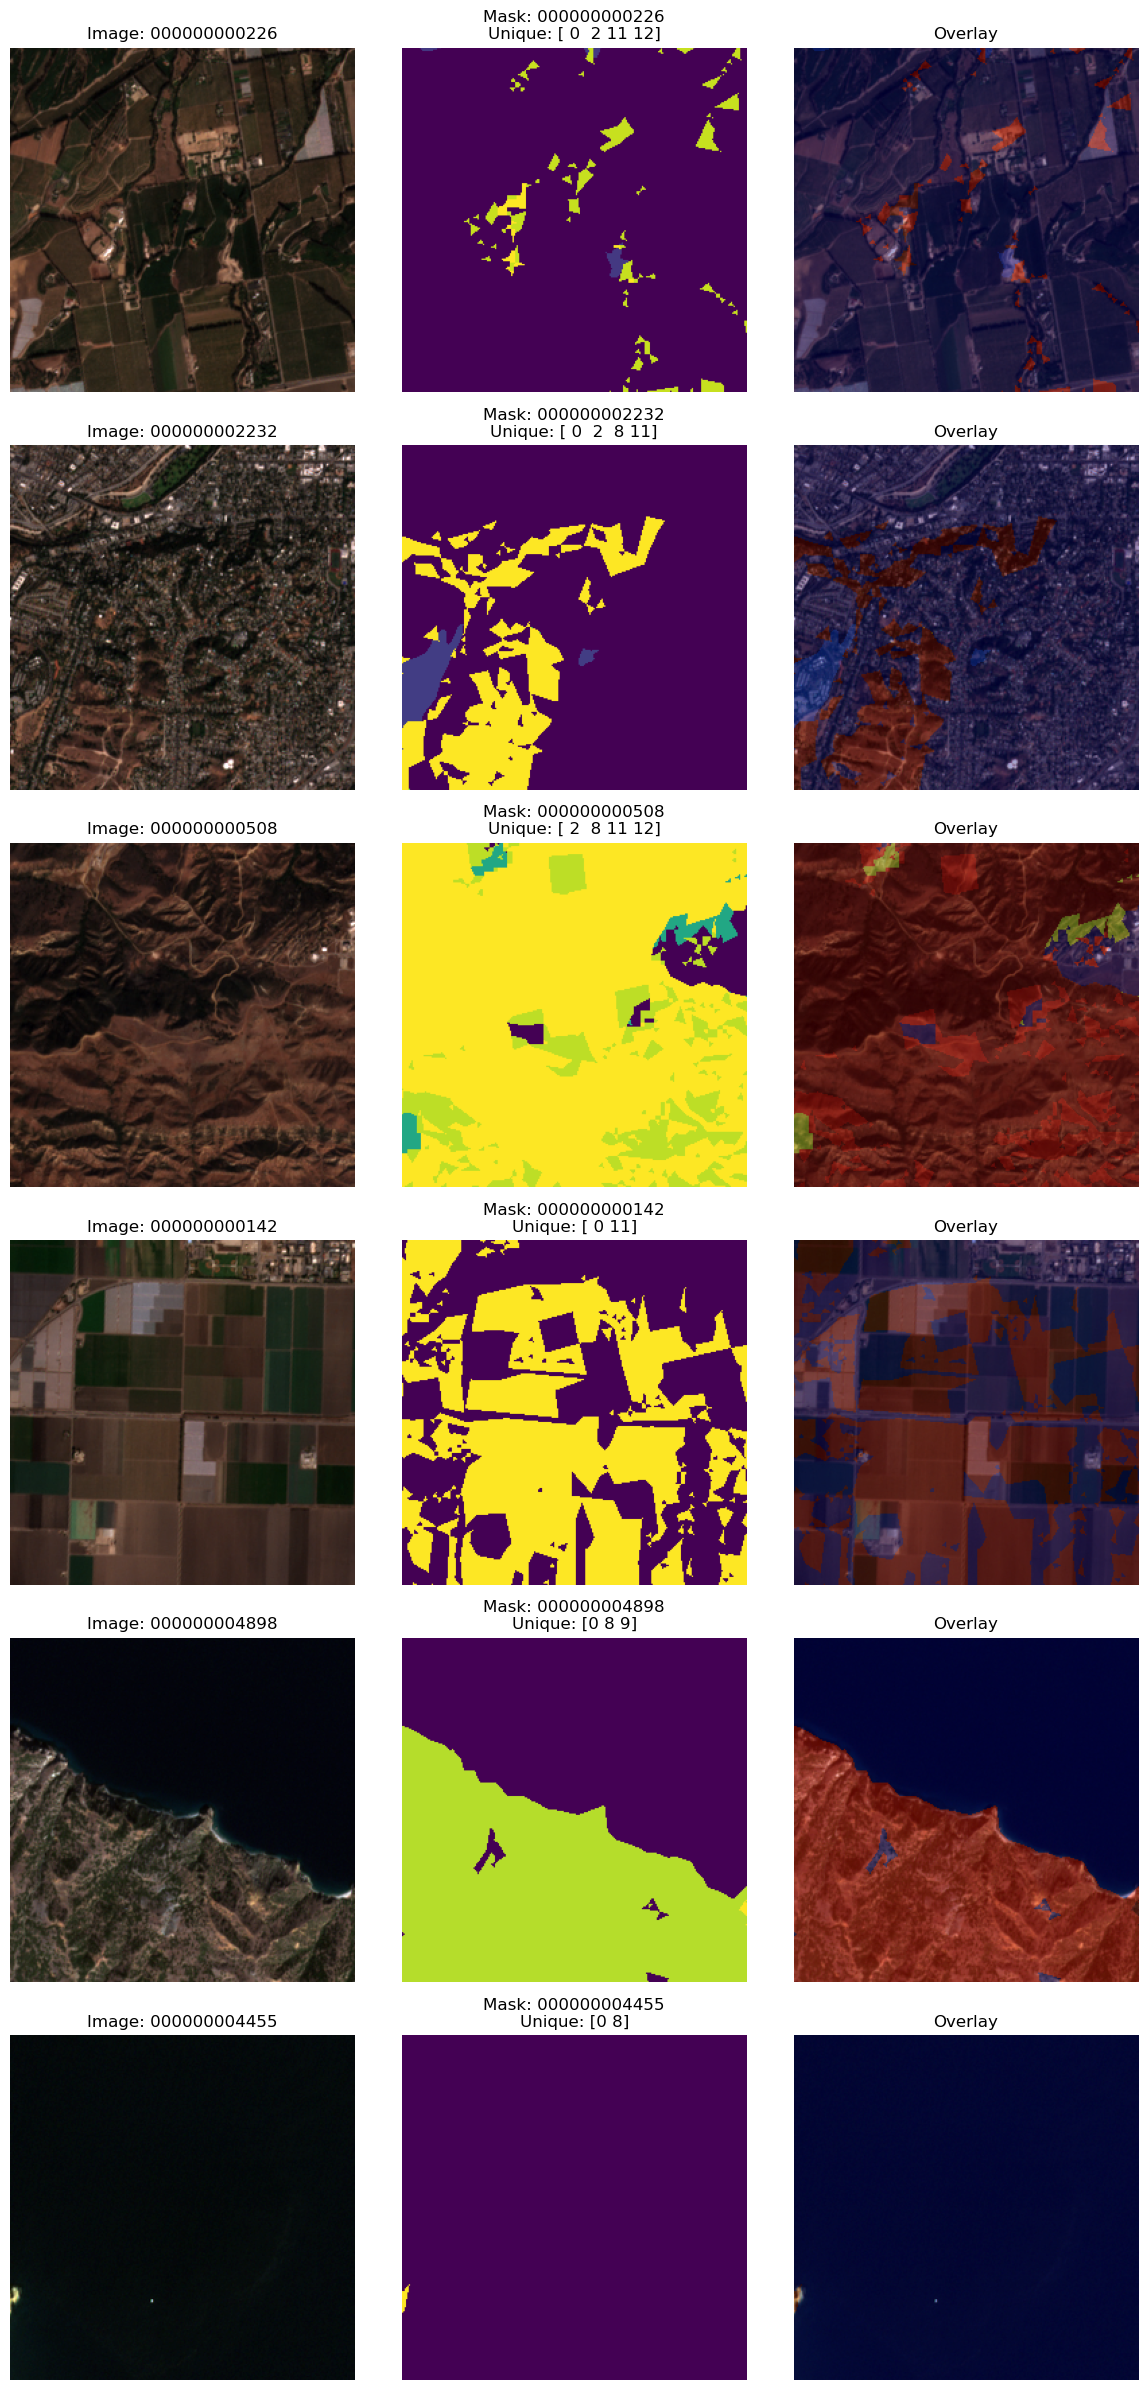

In [54]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import rasterio


# find all dataset folders inside BASE_DIR 
def is_dataset_folder(path):
    return os.path.isdir(path) and "images" in os.listdir(path) and "labels" in os.listdir(path)

dataset_paths = [
    os.path.join(BASE_DIR, d)
    for d in os.listdir(BASE_DIR)
    if is_dataset_folder(os.path.join(BASE_DIR, d))
]

# pick one dataset randomly
dataset_path = random.choice(dataset_paths)
dataset_name = os.path.basename(dataset_path)
# pick one dataset randomly


# manually choose dataset
#dataset_name = "Z3_Roads_Rails_Creek"  # change this to whatever you want
#dataset_path = os.path.join(BASE_DIR, DATASET_NAME)
# manually choose dataset

# sanity check
if not os.path.exists(dataset_path):
    raise ValueError(f"Dataset not found: {dataset_path}")

print("Using dataset:", dataset_name)

# now set image/label paths for that dataset
IMAGES_DIR = os.path.join(dataset_path, "images")
LABELS_DIR = os.path.join(dataset_path, "labels")


# reads image, converts to H, W, C format
def read_image(path):
    with rasterio.open(path) as src:
        arr = src.read()  # (bands, height, width)
    arr = np.transpose(arr, (1, 2, 0))  # -> (height, width, bands)
    return arr
# reads label
def read_mask(path):
    with rasterio.open(path) as src:
        arr = src.read(1)
    return arr
# normalizes image value for display
def normalize_for_display(img):
    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    for c in range(img.shape[2]):
        band = img[:, :, c]
        band_min = band.min()
        band_max = band.max()

        if band_max > band_min:
            out[:, :, c] = (band - band_min) / (band_max - band_min)

    return out

# get matched image-label pairs
image_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(".tif")])
label_files = sorted([f for f in os.listdir(LABELS_DIR) if f.lower().endswith(".tif")])

image_bases = {os.path.splitext(f)[0] for f in image_files}
label_bases = {os.path.splitext(f)[0] for f in label_files}
matched_bases = sorted(image_bases & label_bases)

if len(matched_bases) == 0:
    raise ValueError("No matching image-label pairs found.")

print("Matched image-label pairs:", len(matched_bases))

#Number of random samples to show
N_SAMPLES = 6
sample_bases = random.sample(matched_bases, min(N_SAMPLES, len(matched_bases)))

# creates the figure, row = one sample, column = image/mask overlay
fig, axes = plt.subplots(len(sample_bases), 3, figsize=(12, 4 * len(sample_bases)))

if len(sample_bases) == 1:
    axes = np.expand_dims(axes, axis=0)

#looping through sampled images
for row, base in enumerate(sample_bases):
    img_path = os.path.join(IMAGES_DIR, base + ".tif")
    lbl_path = os.path.join(LABELS_DIR, base + ".tif")

    img = read_image(img_path)
    lbl = read_mask(lbl_path)
    img_disp = normalize_for_display(img)

    # column1: original image
    axes[row, 0].imshow(img_disp)
    axes[row, 0].set_title(f"Image: {base}")
    axes[row, 0].axis("off")

    # oclumn 2: Mask only
    axes[row, 1].imshow(lbl, cmap="viridis")
    axes[row, 1].set_title(f"Mask: {base}\nUnique: {np.unique(lbl)}")
    axes[row, 1].axis("off")

    # column 3: Overlay
    axes[row, 2].imshow(img_disp)
    axes[row, 2].imshow(lbl, cmap="jet", alpha=0.35)
    axes[row, 2].set_title("Overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

Unique values: [ 0 11]


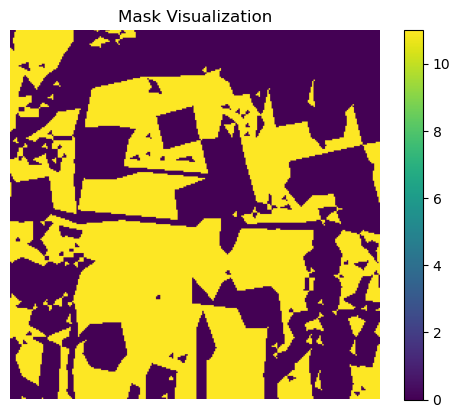

In [55]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

#mask_path = "/home/dfair/Corona/Z6_CalFire_BlueRidge/labels/import matplotlib.pyplot as plt
import rasterio
import numpy as np

mask_path = "C:\\Users\\dylan\\Downloads\\capstoneData\\San Fernando\\San Fernando\\Z3_CalFire_SaddleRidge2\\labels\\000000000142.tif"
with rasterio.open(mask_path) as src:
    mask = src.read(1)

print("Unique values:", np.unique(mask))

plt.imshow(mask, cmap="viridis")
plt.colorbar()
plt.title("Mask Visualization")
plt.axis("off")
plt.show()